# Creating Honeybee BEM models

**Inputs**
- `data/interim/buildings_transformed.pkl` from Stage 4
- `data/interim/archetypes.pkl` from Stage 2
- `data/interim/cities_df.pkl` with city climate classifications
- `config/hb_mappings.json` with climate, program, floor-height, and window mappings

**Steps**
1. Attach the building-stock and climate properties required by Honeybee.
2. Create custom constructions and extrude the Stage 4 zones into rooms.
3. Assign programs and HVAC, add windows, and add neighboring shades.
4. Export and validate the HBJSON files, then review them in the web app.

**Outputs**
- Validated models in `output/hbjsons/`
- Model tables in `data/interim/hbjsons_df.pkl`, `hbjsons_df_full.pkl`, and `buildings_bem.csv`
- An interactive model preview in `output/model_previews/`
- Optional review selections in `data/interim/selected_bad_bem_models.csv`
- Optional rejected models in `output/rejected_bem_models/` and their removed rows in `data/interim/bem_review_removed_tables.pkl`


## Load the Stage 5 inputs

The notebook uses terminal-style progress bars so it does not require Jupyter widgets.

In [1]:
import json

import geopandas as gpd
import pandas as pd
from IPython.display import display

from helpers import bem_inputs, bem_models, bem_outputs
from helpers.GHSL_gridplot import preview_samples
from helpers.hb_constructions import build_construction_sets
from helpers.paths import INTERIM_DIR, PROJECT_ROOT, display_path
from helpers.pickle_compat import read_pickle_compat
from helpers.utils import brief, safe_name

TRANSFORMED_PKL = INTERIM_DIR / "buildings_transformed.pkl"
CITIES_PKL = INTERIM_DIR / "cities_df.pkl"
ARCHETYPES_PKL = INTERIM_DIR / "archetypes.pkl"
MAPPINGS_PATH = PROJECT_ROOT / "config" / "hb_mappings.json"
OUTPUT_DIR = PROJECT_ROOT / "output" / "hbjsons"

N_PREVIEW = 3
MAX_ZONES = 64
ADD_NEIGHBOR_SHADES = True

for path, previous_stage in (
    (TRANSFORMED_PKL, "BEM4AI_4_ModelTransformations.ipynb"),
    (CITIES_PKL, "BEM4AI_1_Cities.ipynb"),
    (ARCHETYPES_PKL, "BEM4AI_2_Archetypes.ipynb"),
    (MAPPINGS_PATH, "the repository config folder"),
):
    if not path.exists():
        raise FileNotFoundError(f"Missing {display_path(path)}. Run or check {previous_stage}.")

artifacts = bem_inputs.load_transformed_artifacts(TRANSFORMED_PKL)
buildings_m = artifacts["buildings_m"]
neighbors_m = artifacts["neighbors_m"]
shades_gdf = artifacts["shades_gdf"]
final_windows_gdf = artifacts["final_windows_gdf"]
cities_df = read_pickle_compat(CITIES_PKL)
archetypes = bem_inputs.load_archetype_bundle(ARCHETYPES_PKL)
with MAPPINGS_PATH.open(encoding="utf-8") as stream:
    hb_config = json.load(stream)

plot_honeybee_models, plot_honeybee_model = bem_outputs.load_plotters(PROJECT_ROOT)
print("Loaded Stage 5 inputs")
for name, value in artifacts.items():
    print(f"  {name}: {brief(value)}")

Loaded Stage 5 inputs
  buildings_m: GeoDataFrame(rows=17, cols=122, crs=None, geom=geometry)
  neighbors_m: GeoDataFrame(rows=77, cols=34, crs=None, geom=geometry)
  shades_gdf: GeoDataFrame(rows=148, cols=6, crs=None, geom=geometry)
  final_windows_gdf: GeoDataFrame(rows=57, cols=3, crs=None, geom=geometry)


### Preview the transformed geometry

Show the first three Stage 4 samples, including their zones, selected window walls, and neighboring shading edges.

(<Figure size 1050x350 with 3 Axes>,
 array([<Axes: title={'center': 'Athens_0001'}>,
        <Axes: title={'center': 'Berlin_0001'}>,
        <Axes: title={'center': 'Birmingham_0001'}>], dtype=object))

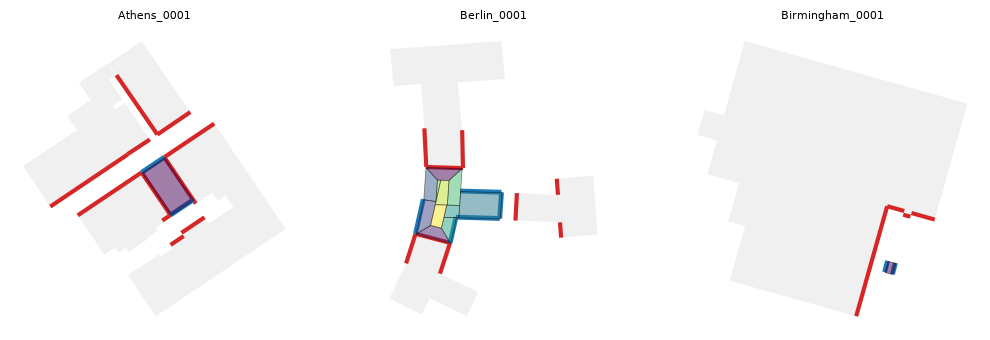

In [2]:
preview_ids = buildings_m["sample_id"].astype(str).head(N_PREVIEW).tolist()
target_crs = buildings_m.crs

main_preview = buildings_m.drop(columns="geometry", errors="ignore").set_geometry(
    "geom_local", crs=target_crs
)
main_preview["zones_parts"] = main_preview["zones"]

neighbor_preview = None
if isinstance(neighbors_m, gpd.GeoDataFrame) and not neighbors_m.empty:
    neighbor_preview = neighbors_m.drop(columns="geometry", errors="ignore").set_geometry(
        "geom_local", crs=target_crs
    )

preview_samples(
    main_preview,
    [
        {
            "name": "neighbors",
            "gdf": neighbor_preview,
            "role": "neighbor",
            "color": "#f0f0f0",
            "edgecolor": "none",
        },
        {
            "name": "shading edges",
            "gdf": shades_gdf,
            "role": "edge",
            "color": "#d62728",
            "linewidth": 3.0,
        },
        {
            "name": "window walls",
            "gdf": final_windows_gdf,
            "role": "edge",
            "color": "#1f77b4",
            "linewidth": 3.5,
        },
        {
            "name": "zones",
            "gdf": main_preview,
            "role": "main",
            "parts_col": "zones_parts",
            "cmap": "viridis",
            "edgecolor": "black",
            "alpha": 0.5,
        },
    ],
    ids=preview_ids,
    ncols=N_PREVIEW,
    figsize_scale=3.5,
    linewidth=0.5,
    share_aspect_equal=True,
    tight_layout=True,
)

## Prepare the building properties

### Match building-stock, age, climate, and construction data

**Inputs**: Stage 4 buildings, city climate data, the Stage 2 archetype tables, and `hb_mappings.json`.

**Outputs**: `buildings_bem`, the excluded-input table, and one custom Honeybee construction set per retained building.

In [3]:
buildings_m, building_types_df = bem_inputs.prepare_bem_inputs(
    buildings_m, cities_df, archetypes, hb_config
)
buildings_bem, excluded_buildings_bem = bem_inputs.filter_bem_inputs(buildings_m)
buildings_bem, excluded_buildings_bem, construction_sets_by_sample = build_construction_sets(
    buildings_bem, excluded_buildings_bem
)

print(f"BEM-ready buildings: {len(buildings_bem)} / {len(buildings_m)}")
print(f"Excluded before geometry generation: {len(excluded_buildings_bem)}")
if not excluded_buildings_bem.empty:
    input_reason_counts = (
        excluded_buildings_bem["bem_exclusion_reasons"].explode().value_counts()
    )
    display(input_reason_counts.rename_axis("reason").reset_index(name="count"))

display(
    buildings_bem[
        ["sample_id", "country_id", "building_type_id", "age_class_id", "hb_construction_set_id"]
    ].head(N_PREVIEW)
)

BEM-ready buildings: 17 / 17
Excluded before geometry generation: 0


,sample_id,country_id,building_type_id,age_class_id,hb_construction_set_id
0,Athens_0001,12,5,2,pre_1980::ClimateZone3::Mass
1,Berlin_0001,11,3,2,pre_1980::ClimateZone4::Mass
2,Birmingham_0001,28,4,2,pre_1980::ClimateZone4::Mass


## Build the Honeybee models

### Estimate floors and assemble room geometry

The building height is divided into a plausible integer number of floors. Each Stage 4 zone is then extruded on every floor, added to a Honeybee model, and matched to adjacent rooms.

Building Honeybee geometry: 100%|██████████| 17/17 [00:04<00:00,  3.93building/s]

Created 17 models with 424 rooms


,sample_id,builth_val,levels_est,level_height_m
0,Athens_0001,14.410562,5,2.9
1,Berlin_0001,17.114628,6,2.9
2,Birmingham_0001,11.122563,4,2.8


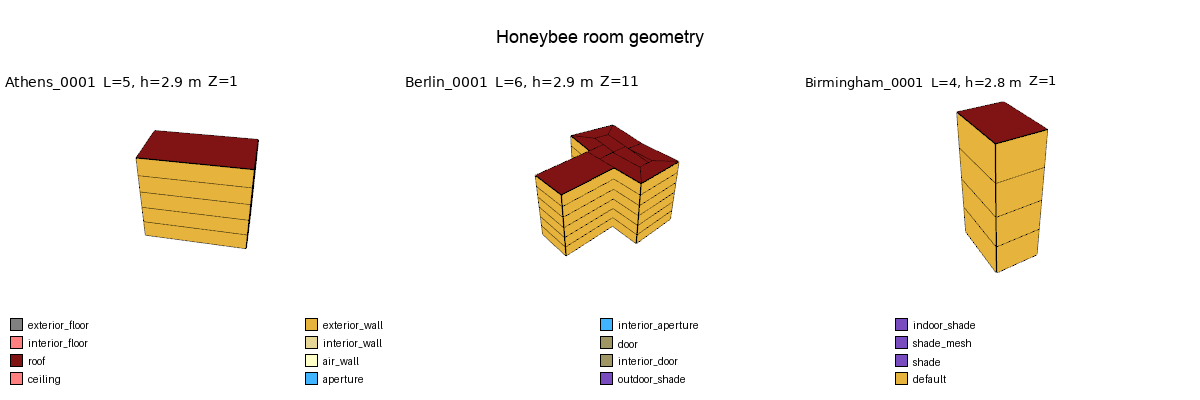

In [4]:
buildings_bem = bem_inputs.estimate_floors(buildings_bem, hb_config)
models_dict = bem_models.build_geometry_models(buildings_bem)
preview_ids = list(models_dict)[:N_PREVIEW]

print(f"Created {len(models_dict)} models with {sum(len(model.rooms) for model in models_dict.values())} rooms")
display(buildings_bem[["sample_id", "builth_val", "levels_est", "level_height_m"]].head(N_PREVIEW))

bem_outputs.preview_models(
    plot_honeybee_models,
    models_dict,
    buildings_bem,
    preview_ids,
    title="Honeybee room geometry",
)

### Assign programs, constructions, and HVAC

Residential programs are selected from the estimated floor count. Non-residential programs follow the building-type mapping in `hb_mappings.json`. Every room receives its building's custom construction set and an ideal-loads HVAC system.

In [5]:
buildings_bem = bem_models.assign_energy_properties(
    models_dict,
    buildings_bem,
    construction_sets_by_sample,
    building_types_df,
    hb_config,
)
display(
    buildings_bem[
        ["sample_id", "building_type_id", "levels_est", "hb_program_identifier"]
    ].head(N_PREVIEW)
)

Assigned programs, constructions, and ideal HVAC to 424 rooms


,sample_id,building_type_id,levels_est,hb_program_identifier
0,Athens_0001,5,5,pre_1980::Retail::Retail
1,Berlin_0001,3,6,pre_1980::MidriseApartment::Apartment
2,Birmingham_0001,4,4,pre_1980::LargeOffice::OpenOffice


### Add windows

Stage 4 identifies exterior wall segments that can host windows. Stage 5 applies the building-type window dimensions and ratios from `hb_mappings.json` to the corresponding Honeybee faces.

Adding windows: 100%|██████████| 17/17 [00:00<00:00, 133.76building/s]


Buildings with windows: 17 / 17
Total windows: 1759


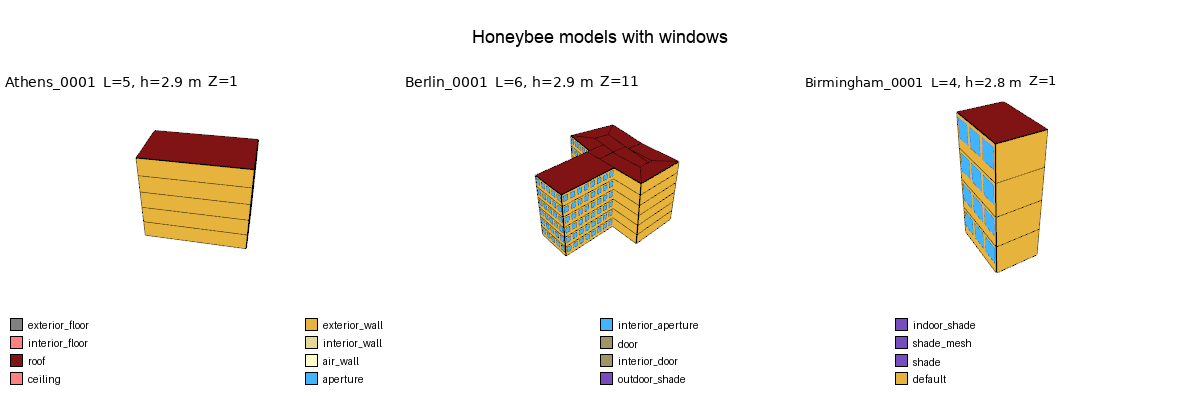

In [6]:
apertures_by_sample = bem_models.add_windows(
    models_dict,
    buildings_bem,
    final_windows_gdf,
    building_types_df,
    hb_config,
)
print(f"Buildings with windows: {sum(count > 0 for count in apertures_by_sample.values())} / {len(models_dict)}")
print(f"Total windows: {sum(apertures_by_sample.values())}")

bem_outputs.preview_models(
    plot_honeybee_models,
    models_dict,
    buildings_bem,
    preview_ids,
    title="Honeybee models with windows",
)

### Add neighboring shades

The selected neighboring edges from Stage 4 are extruded to the target building height and added as context shades. Set `ADD_NEIGHBOR_SHADES = False` in the input cell to omit them.

Adding neighboring shades: 100%|██████████| 16/16 [00:00<00:00, 2375.28building/s]

Neighbor shades added: 148


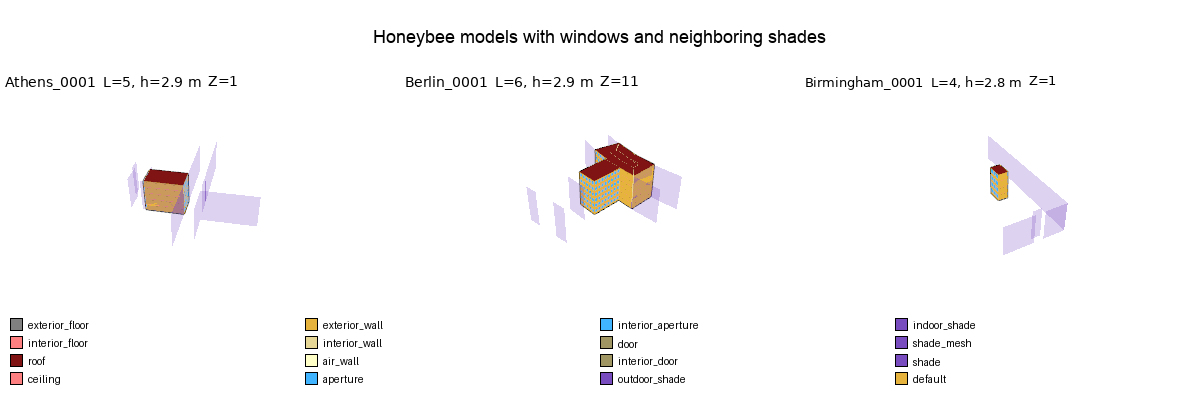

In [7]:
shades_by_sample = bem_models.add_neighbor_shades(
    models_dict,
    buildings_bem,
    shades_gdf,
    enabled=ADD_NEIGHBOR_SHADES,
)
print(f"Neighbor shades added: {sum(shades_by_sample.values())}")

bem_outputs.preview_models(
    plot_honeybee_models,
    models_dict,
    buildings_bem,
    preview_ids,
    title="Honeybee models with windows and neighboring shades",
)

### Inspect one model interactively

Choose `DEMO_SAMPLE_ID` or leave it as `None` to inspect the first model. The preview is displayed here and saved under `output/model_previews/`.

In [8]:
DEMO_SAMPLE_ID = None

if not models_dict:
    raise ValueError("No Honeybee models are available for interactive preview.")
demo_sample_id = str(DEMO_SAMPLE_ID) if DEMO_SAMPLE_ID is not None else next(iter(models_dict))
if demo_sample_id not in models_dict:
    raise KeyError(f"Unknown DEMO_SAMPLE_ID {demo_sample_id!r}.")

interactive_figure = plot_honeybee_model(
    model=models_dict[demo_sample_id],
    title=demo_sample_id,
    surface_opacity=1.0,
    show_wireframe=True,
    show_legend=True,
    show=False,
)
preview_dir = PROJECT_ROOT / "output" / "model_previews"
preview_dir.mkdir(parents=True, exist_ok=True)
interactive_preview_path = (preview_dir / f"{safe_name(demo_sample_id, 'honeybee_model')}.html").resolve()
interactive_figure.write_html(str(interactive_preview_path), include_plotlyjs=True, full_html=True)
interactive_figure.show(config={"scrollZoom": True, "displaylogo": False})
print(f"Saved interactive preview: {display_path(interactive_preview_path)}")

Saved interactive preview: output/model_previews/Athens_0001.html


## Export and validate the HBJSON models

Each exported file must pass Honeybee validation, contain at least one Zone and one window, and stay within the publication limit of 64 Zones. Models that fail any check are removed immediately. The displayed counts explain every automatic removal; no separate validation-audit file is written.

In [9]:
hbjsons_df_full, hbjsons_df, validation_rejections = bem_outputs.export_validate_and_index(
    models_dict,
    buildings_bem,
    OUTPUT_DIR,
    INTERIM_DIR,
    has_neighbor_shades=ADD_NEIGHBOR_SHADES,
    minimum_windows=1,
    maximum_zones=MAX_ZONES,
)

reason_series = []
if not excluded_buildings_bem.empty:
    reason_series.append(excluded_buildings_bem["bem_exclusion_reasons"].explode())
if not validation_rejections.empty:
    reason_series.append(validation_rejections["removal_reasons"].explode())

print(f"Valid HBJSON models: {len(hbjsons_df)}")
print(f"Models removed automatically: {len(buildings_m) - len(hbjsons_df)}")
if reason_series:
    removal_counts = pd.concat(reason_series).dropna().value_counts()
    print("Removal reasons:")
    for reason, count in removal_counts.items():
        print(f"  {reason}: {count}")

honeybee_failures = validation_rejections[
    validation_rejections["validation_message"].astype(str).str.len().gt(0)
]
if not honeybee_failures.empty:
    display(honeybee_failures[["sample_id", "removal_reasons", "validation_message"]].head(N_PREVIEW))

buildings_bem = hbjsons_df_full
print(f"Saved model index: {display_path(INTERIM_DIR / 'hbjsons_df.pkl')}")

Validating HBJSON models: 100%|██████████| 17/17 [00:01<00:00, 10.58model/s]

Valid HBJSON models: 13
Models removed automatically: 4
Removal reasons:
  zones_above_64: 4
Saved model index: data/interim/hbjsons_df.pkl


## Review generated BEM models

The optional web app displays the exported models and records rejected `sample_id` values in `data/interim/selected_bad_bem_models.csv`. Run the next cell, review the models in the browser, and then run the final cell to apply the saved selections.

In [10]:
from helpers.review_app import launch, link

BEM_REVIEW_CSV = INTERIM_DIR / "selected_bad_bem_models.csv"
HBJSONS_FULL_PKL = INTERIM_DIR / "hbjsons_df_full.pkl"
HBJSONS_SMALL_PKL = INTERIM_DIR / "hbjsons_df.pkl"

review_url = launch(
    "scripts.review_apps.serve_bem_selector",
    hbjsons_full_path=HBJSONS_FULL_PKL,
    hbjsons_small_path=HBJSONS_SMALL_PKL,
    output_dir=OUTPUT_DIR,
    csv_path=BEM_REVIEW_CSV,
    transformed_path=TRANSFORMED_PKL,
)
print(f"Selections are saved to {display_path(BEM_REVIEW_CSV)}")
link(review_url, "Open the BEM review app")

Selections are saved to data/interim/selected_bad_bem_models.csv


### Apply the saved review selections

Remove selected models from the Stage 5 tables and move their HBJSON files to `output/rejected_bem_models/`. Re-running the cell does not remove anything twice.

In [13]:
from helpers.review_selections import apply_bem_review_selections

REJECTED_BEM_ROOT = PROJECT_ROOT / "output" / "rejected_bem_models"
review_report = apply_bem_review_selections(
    csv_path=BEM_REVIEW_CSV,
    table_paths=[
        INTERIM_DIR / "hbjsons_df.pkl",
        INTERIM_DIR / "hbjsons_df_full.pkl",
        INTERIM_DIR / "buildings_bem.csv",
    ],
    artifact_dirs=[OUTPUT_DIR],
    removed_tables_path=INTERIM_DIR / "bem_review_removed_tables.pkl",
    rejected_artifact_root=REJECTED_BEM_ROOT,
)

if not review_report["selected_ids"]:
    print("Nothing is selected for removal; the model artifacts are unchanged.")
elif review_report["removed_model_ids"]:
    removed_models = len(review_report["removed_model_ids"])
    model_label = "model" if removed_models == 1 else "models"
    print(f"Removed {removed_models} {model_label} and updated the model tables.")
    print(f"Rejected artifacts: {display_path(REJECTED_BEM_ROOT)}")
else:
    print("No additional models were removed; the model tables are already up to date.")
if review_report["unknown_ids"]:
    print(f"Selected IDs not found in the artifacts: {review_report['unknown_ids']}")

hbjsons_df_full = read_pickle_compat(INTERIM_DIR / "hbjsons_df_full.pkl")
hbjsons_df = read_pickle_compat(INTERIM_DIR / "hbjsons_df.pkl")

Removed 1 model and updated the model tables.
Rejected artifacts: output/rejected_bem_models
